In [1]:
# notebook to plot vlambda vs vbeta of different populations from S3M

In [2]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [3]:
import importlib
import s3m_loader
importlib.reload(s3m_loader)

<module 's3m_loader' from '/home/devanshi-s04/notebooks/neomod/s3m_loader.py'>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import NEOfaster as nf
import NEOMOD3 as nm3
import neoscore as nsc
import neoom as no
import S3Marray as sm
import S3M_fullversion as smfull
import neoonlyS3M as neo3m
import trojans as tjn
import tnos as tn

#new s3m loader
import s3m_loader as load_s3m
# bleh

import importlib
from functools import reduce
importlib.reload(nm3)
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [5]:
s3m = s3m_loader.define_s3m("mba", verbose=True)  # defaults to pop="mba"

Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S1_00.s3m', './S1_01.s3m', './S1_02.s3m', './S1_03.s3m', './S1_04.s3m', './S1_05.s3m', './S1_06.s3m', './S1_07.s3m', './S1_08.s3m', './S1_09.s3m', './S1_10.s3m', './S1_11.s3m', './S1_12.s3m', './S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.


In [6]:
s3m, array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = load_s3m.s3m_array(s3m)
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

In [7]:
obstime_str = "2025-09-23T00:00:00"
mag = 24.0

Using ALL rows: 13883361


Propagate with newton: 100%|██████████| 47/47 [00:10<00:00,  4.27it/s]


anti-sun RA,Dec: 180.2447707411587 -0.10555404868149516
After anti-sun sep < 30.0°: 1409982


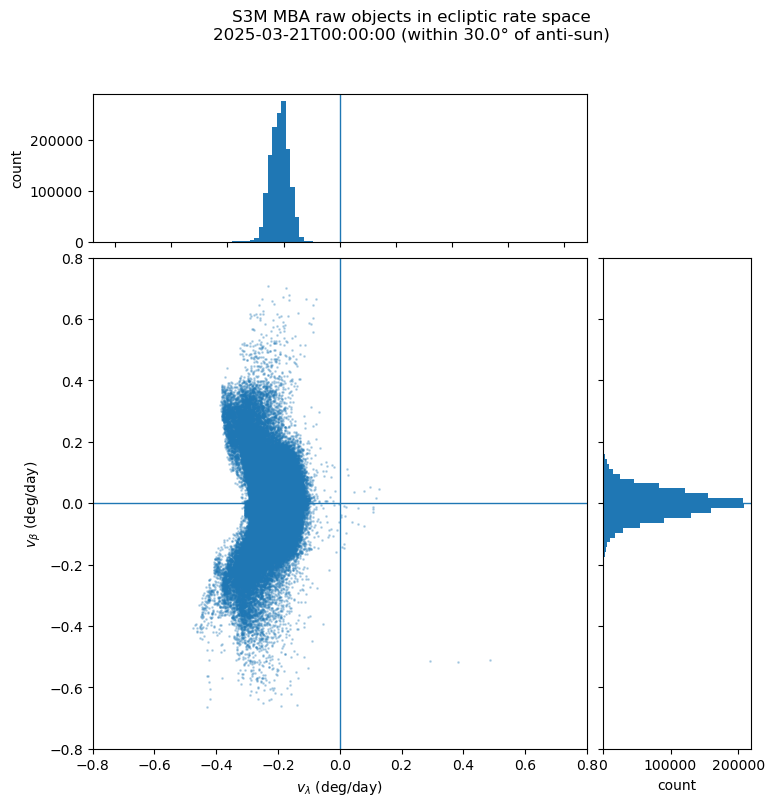

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, GCRS, get_sun

obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2

#Pull columns

a_AU   = s3m["a"].to_numpy(dtype=float)
e      = s3m["e"].to_numpy(dtype=float)
inc    = s3m["i"].to_numpy(dtype=float)        # deg
raan   = s3m["node"].to_numpy(dtype=float)     # deg
argp   = s3m["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = s3m["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))



r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)


#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_mba_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)


good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

print("anti-sun RA,Dec:", anti_ra_deg, anti_dec_deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg


m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))




# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]

# copying vlam/vbet values

vlam_mba  = vlam.copy()
vbeta_mba = vbeta.copy()

# Scatter + marginal histograms 

fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[4.0, 1.2],
    height_ratios=[1.2, 4.0],
    wspace=0.05, hspace=0.05
)

ax_histx = fig.add_subplot(gs[0, 0])
ax_scatt = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatt)

# Scatter
ax_scatt.scatter(vlam, vbeta, s=1, alpha=0.25)
ax_scatt.axhline(0, lw=1)
ax_scatt.axvline(0, lw=1)
ax_scatt.set_xlabel(r"$v_\lambda$ (deg/day)")
ax_scatt.set_ylabel(r"$v_\beta$ (deg/day)")
ax_scatt.set_xlim(*xlim)
ax_scatt.set_ylim(*ylim)

# Top histogram (v_lambda)
ax_histx.hist(vlam, bins=bins, range=xlim)
ax_histx.axvline(0, lw=1)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.set_ylabel("count")

# Right histogram (v_beta)
ax_histy.hist(vbeta, bins=bins, range=ylim, orientation="horizontal")
ax_histy.axhline(0, lw=1)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.set_xlabel("count")

fig.suptitle(f"S3M MBA raw objects in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)", y=0.98)
plt.show()



#### same plot but w NEOs

In [27]:
neo = load_s3m.define_s3m(pop="neo")
neo, array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = load_s3m.s3m_array(neo)
scorer_neo_s3m = nsc.NEOMODScorer(array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo)

Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.


Using ALL rows: 268511


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00,  5.01it/s]


After good-mask: 268511
After anti-sun sep < 30.0°: 13485
Finite vlam/vbeta: 13485


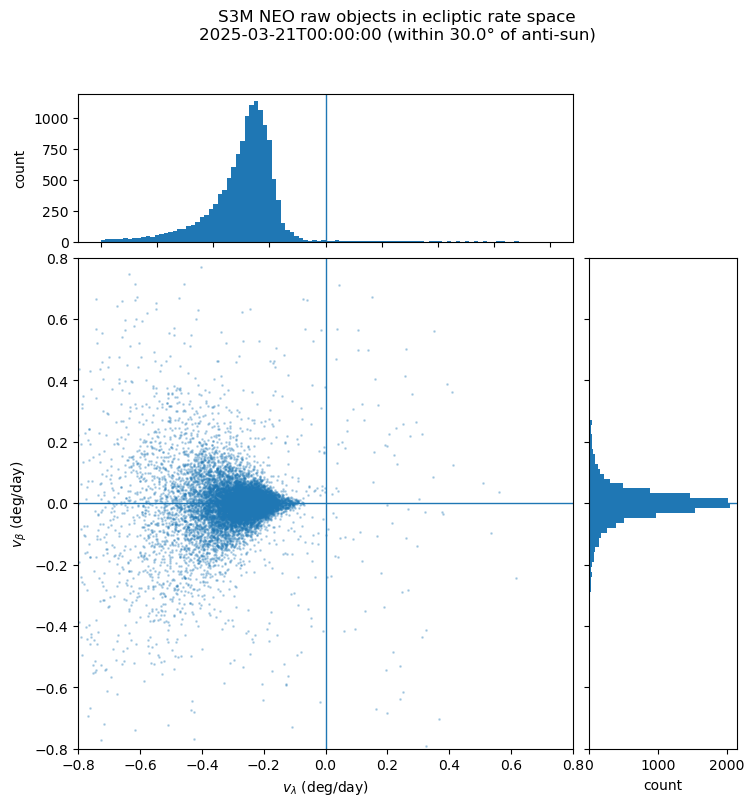

In [28]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2

#Pull columns

a_AU   = neo["a"].to_numpy(dtype=float)
e      = neo["e"].to_numpy(dtype=float)
inc    = neo["i"].to_numpy(dtype=float)        # deg
raan   = neo["node"].to_numpy(dtype=float)     # deg
argp   = neo["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = neo["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))


r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)


#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_neo_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

print("After good-mask:", len(ra_deg))


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))


# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]
print("Finite vlam/vbeta:", len(vlam))

# copying vlam/vbet values
vlam_neo  = vlam.copy()
vbeta_neo = vbeta.copy()


# Scatter + marginal histograms 

fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[4.0, 1.2],
    height_ratios=[1.2, 4.0],
    wspace=0.05, hspace=0.05
)

ax_histx = fig.add_subplot(gs[0, 0])
ax_scatt = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatt)

# Scatter
ax_scatt.scatter(vlam, vbeta, s=1, alpha=0.25)
ax_scatt.axhline(0, lw=1)
ax_scatt.axvline(0, lw=1)
ax_scatt.set_xlabel(r"$v_\lambda$ (deg/day)")
ax_scatt.set_ylabel(r"$v_\beta$ (deg/day)")
ax_scatt.set_xlim(*xlim)
ax_scatt.set_ylim(*ylim)

# Top histogram (v_lambda)
ax_histx.hist(vlam, bins=bins, range=xlim)
ax_histx.axvline(0, lw=1)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.set_ylabel("count")

# Right histogram (v_beta)
ax_histy.hist(vbeta, bins=bins, range=ylim, orientation="horizontal")
ax_histy.axhline(0, lw=1)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.set_xlabel("count")

fig.suptitle(f"S3M NEO raw objects in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)", y=0.98)
plt.show()



### TNOS!!!

In [38]:
tno = load_s3m.define_s3m(pop="tno")
tno, array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno = load_s3m.s3m_array(tno)
scorer_tno_s3m = nsc.NEOMODScorer(array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno)

['ST.s3m']
The final df is done.


Using ALL rows: 48682


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 24.80it/s]

After good-mask: 48682
After anti-sun sep < 30.0°: 7417
Finite vlam/vbeta: 7417


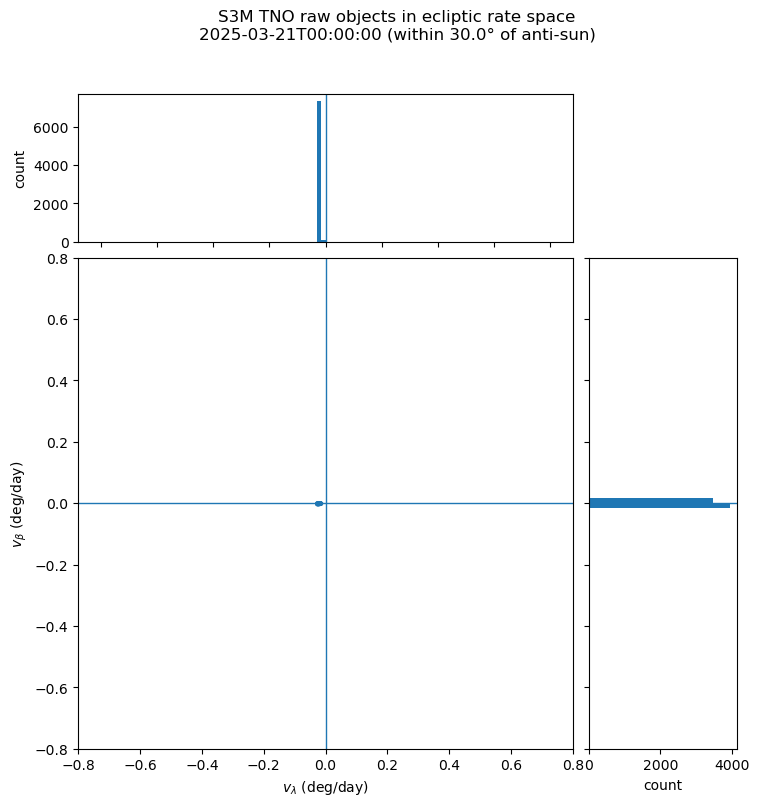

In [56]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2

#Pull columns

a_AU   = tno["a"].to_numpy(dtype=float)
e      = tno["e"].to_numpy(dtype=float)
inc    = tno["i"].to_numpy(dtype=float)        # deg
raan   = tno["node"].to_numpy(dtype=float)     # deg
argp   = tno["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = tno["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))


r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)

#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_tno_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

print("After good-mask:", len(ra_deg))


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))


# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]
print("Finite vlam/vbeta:", len(vlam))

# copying vlam/vbet values
vlam_tno  = vlam.copy()
vbeta_tno = vbeta.copy()


# Scatter + marginal histograms 

fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[4.0, 1.2],
    height_ratios=[1.2, 4.0],
    wspace=0.05, hspace=0.05
)

ax_histx = fig.add_subplot(gs[0, 0])
ax_scatt = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatt)

# Scatter
ax_scatt.scatter(vlam, vbeta, s=1, alpha=0.25)
ax_scatt.axhline(0, lw=1)
ax_scatt.axvline(0, lw=1)
ax_scatt.set_xlabel(r"$v_\lambda$ (deg/day)")
ax_scatt.set_ylabel(r"$v_\beta$ (deg/day)")
ax_scatt.set_xlim(*xlim)
ax_scatt.set_ylim(*ylim)

# Top histogram (v_lambda)
ax_histx.hist(vlam, bins=bins, range=xlim)
ax_histx.axvline(0, lw=1)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.set_ylabel("count")

# Right histogram (v_beta)
ax_histy.hist(vbeta, bins=bins, range=ylim, orientation="horizontal")
ax_histy.axhline(0, lw=1)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.set_xlabel("count")

fig.suptitle(f"S3M TNO raw objects in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)", y=0.98)
plt.show()


### trojan empire

In [40]:
trojan = load_s3m.define_s3m(pop="trojan")
trojan,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = load_s3m.s3m_array(trojan)
scorer_tjn_s3m = nsc.NEOMODScorer(array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)

['St5.s3m']
The final df is done.


Using ALL rows: 179882


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00,  6.62it/s]


After good-mask: 179882
After anti-sun sep < 30.0°: 23188
Finite vlam/vbeta: 23188


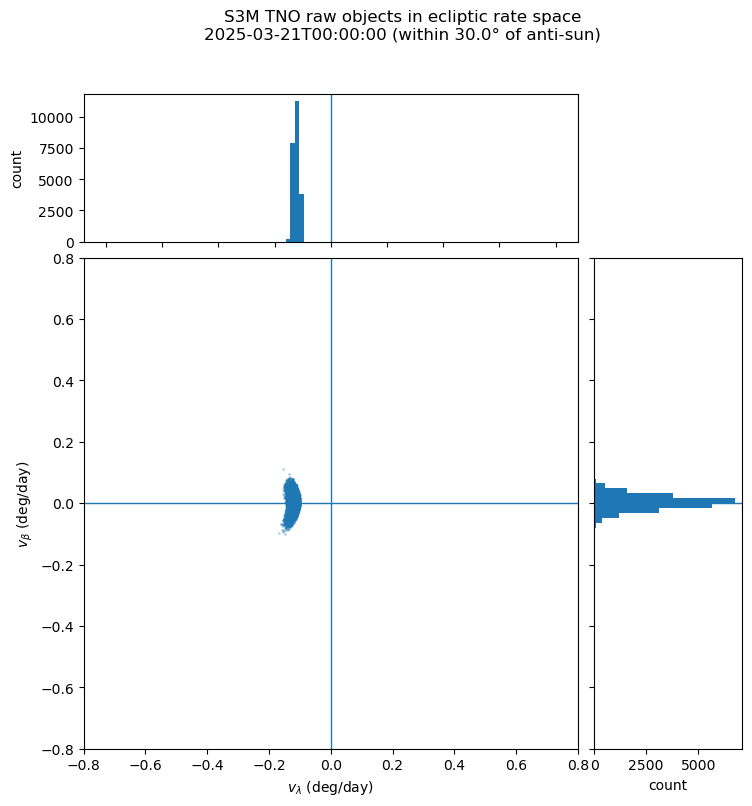

In [57]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2

#Pull columns

a_AU   = trojan["a"].to_numpy(dtype=float)
e      = trojan["e"].to_numpy(dtype=float)
inc    = trojan["i"].to_numpy(dtype=float)        # deg
raan   = trojan["node"].to_numpy(dtype=float)     # deg
argp   = trojan["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = trojan["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))


r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)


#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_tjn_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

print("After good-mask:", len(ra_deg))


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))


# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]
print("Finite vlam/vbeta:", len(vlam))

# copying vlam/vbet values
vlam_tjn  = vlam.copy()
vbeta_tjn = vbeta.copy()


# Scatter + marginal histograms 

fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[4.0, 1.2],
    height_ratios=[1.2, 4.0],
    wspace=0.05, hspace=0.05
)

ax_histx = fig.add_subplot(gs[0, 0])
ax_scatt = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatt)

# Scatter
ax_scatt.scatter(vlam, vbeta, s=1, alpha=0.25)
ax_scatt.axhline(0, lw=1)
ax_scatt.axvline(0, lw=1)
ax_scatt.set_xlabel(r"$v_\lambda$ (deg/day)")
ax_scatt.set_ylabel(r"$v_\beta$ (deg/day)")
ax_scatt.set_xlim(*xlim)
ax_scatt.set_ylim(*ylim)

# Top histogram (v_lambda)
ax_histx.hist(vlam, bins=bins, range=xlim)
ax_histx.axvline(0, lw=1)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.set_ylabel("count")

# Right histogram (v_beta)
ax_histy.hist(vbeta, bins=bins, range=ylim, orientation="horizontal")
ax_histy.axhline(0, lw=1)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.set_xlabel("count")

fig.suptitle(f"S3M TNO raw objects in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)", y=0.98)
plt.show()



### full s3m but i think it should look messy

In [16]:
fulls3m = load_s3m.define_s3m(pop="all")
fulls3m,array4D_fs3m, H_center_fs3m, a_center_fs3m, e_center_fs3m, i_center_fs3m = load_s3m.s3m_array(fulls3m)
scorer_full_s3m = nsc.NEOMODScorer(array4D_fs3m, H_center_fs3m, a_center_fs3m, e_center_fs3m, i_center_fs3m)

['S0.s3m', 'S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m', 'SH.s3m', 'SI.s3m', 'SJ.s3m', 'SL.s3m', 'SR.s3m', 'SS.s3m', 'ST.s3m', 'St5.s3m']
The final df is done.


/home/devanshi-s04/.local/lib/python3.12/site-packages/numpy/core/function_base.py:158: RuntimeWarning: invalid value encountered in multiply
  y *= step
/home/devanshi-s04/.local/lib/python3.12/site-packages/numpy/lib/function_base.py:1452: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


Using ALL rows: 14608605


/tmp/ipykernel_4989/2025621748.py:42: RuntimeWarning: invalid value encountered in sqrt
  n = np.sqrt(mu_sun / (a_km**3))              # rad/s
Propagate & solve Kepler:  96%|█████████▌| 47/49 [00:11<00:00,  3.66it/s]/tmp/ipykernel_4989/2025621748.py:69: RuntimeWarning: invalid value encountered in divide
  E_c -= (E_c - e_c*np.sin(E_c) - M_c) / (1 - e_c*np.cos(E_c))
/tmp/ipykernel_4989/2025621748.py:73: RuntimeWarning: invalid value encountered in sqrt
  sqrt1me2 = np.sqrt(1 - e_c*e_c)
/tmp/ipykernel_4989/2025621748.py:80: RuntimeWarning: invalid value encountered in multiply
  p = a_km_c * (1 - e_c*e_c)
Propagate & solve Kepler: 100%|██████████| 49/49 [00:12<00:00,  3.99it/s]


After good-mask: 14519074
After anti-sun sep < 30.0°: 1471223
Finite vlam/vbeta: 1471223


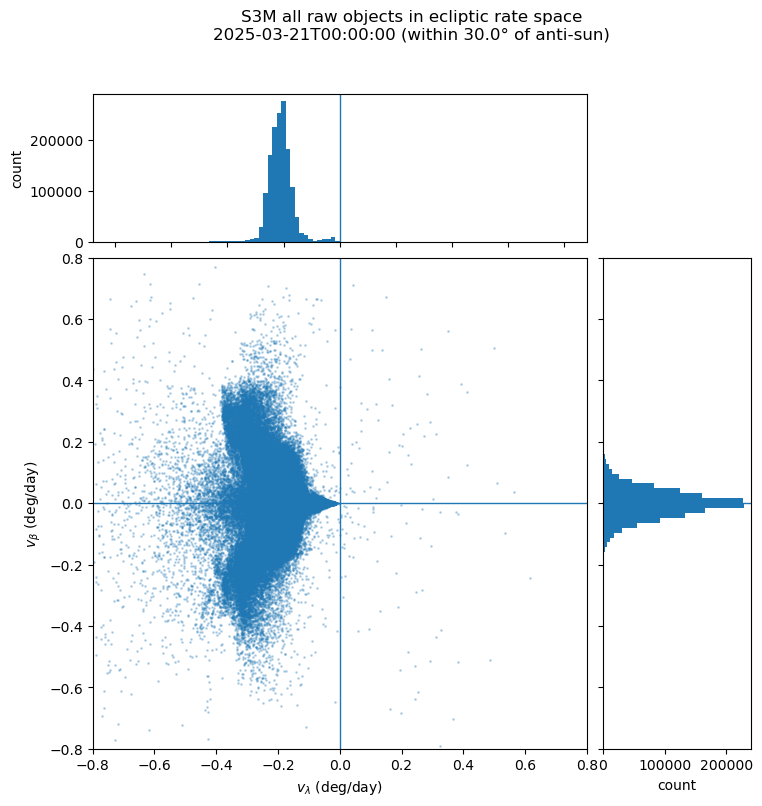

In [17]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2

#Pull columns

a_AU   = fulls3m["a"].to_numpy(dtype=float)
e      = fulls3m["e"].to_numpy(dtype=float)
inc    = fulls3m["i"].to_numpy(dtype=float)        # deg
raan   = fulls3m["node"].to_numpy(dtype=float)     # deg
argp   = fulls3m["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = fulls3m["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))


# Propagate Kepler orbits to obstime -> heliocentric ecliptic (r,v)
# Elements: (a, e, i, Ω, ω, tp)
#tqdm timing: Kepler solve in chunks so tqdm can track progress

a_km = a_AU * AU_km

inc_r  = np.deg2rad(inc)
raan_r = np.deg2rad(raan)
argp_r = np.deg2rad(argp)

n = np.sqrt(mu_sun / (a_km**3))              # rad/s
dt_s = (t_obs.mjd - tp_mjd) * 86400.0        # seconds
M = np.mod(n * dt_s, 2*np.pi)                # mean anomaly in [0, 2pi)


rx_ecl = np.empty_like(a_km)
ry_ecl = np.empty_like(a_km)
rz_ecl = np.empty_like(a_km)
vx_ecl = np.empty_like(a_km)
vy_ecl = np.empty_like(a_km)
vz_ecl = np.empty_like(a_km)

chunk = 300_000  # chunk size for tqdm 

for k0 in tqdm(range(0, len(a_km), chunk), desc="Propagate & solve Kepler"):
    k1 = min(k0 + chunk, len(a_km))

    a_km_c = a_km[k0:k1]
    e_c    = e[k0:k1]
    inc_c  = inc_r[k0:k1]
    raan_c = raan_r[k0:k1]
    argp_c = argp_r[k0:k1]
    M_c    = M[k0:k1]

    # Solving Kepler: M = E - e sin E (Newton iterations)
    E_c = M_c.copy()
    for _ in range(10):
        E_c -= (E_c - e_c*np.sin(E_c) - M_c) / (1 - e_c*np.cos(E_c))

    cosE = np.cos(E_c)
    sinE = np.sin(E_c)
    sqrt1me2 = np.sqrt(1 - e_c*e_c)

    cosf = (cosE - e_c) / (1 - e_c*cosE)
    sinf = (sqrt1me2 * sinE) / (1 - e_c*cosE)
    f_true = np.arctan2(sinf, cosf)

    r = a_km_c * (1 - e_c*cosE)
    p = a_km_c * (1 - e_c*e_c)
    h = np.sqrt(mu_sun * p)

    # PQW position/velocity
    x_p  = r * np.cos(f_true)
    y_p  = r * np.sin(f_true)
    vx_p = -mu_sun/h * np.sin(f_true)
    vy_p =  mu_sun/h * (e_c + np.cos(f_true))

    # Rotation PQW -> ecliptic IJK  (Rz(Ω) Rx(i) Rz(ω))
    cO, sO = np.cos(raan_c), np.sin(raan_c)
    ci, si = np.cos(inc_c),  np.sin(inc_c)
    cw, sw = np.cos(argp_c), np.sin(argp_c)

    R11 = cO*cw - sO*sw*ci
    R12 = -cO*sw - sO*cw*ci
    R21 = sO*cw + cO*sw*ci
    R22 = -sO*sw + cO*cw*ci
    R31 = sw*si
    R32 = cw*si

    rx_ecl[k0:k1] = R11*x_p + R12*y_p
    ry_ecl[k0:k1] = R21*x_p + R22*y_p
    rz_ecl[k0:k1] = R31*x_p + R32*y_p

    vx_ecl[k0:k1] = R11*vx_p + R12*vy_p
    vy_ecl[k0:k1] = R21*vx_p + R22*vy_p
    vz_ecl[k0:k1] = R31*vx_p + R32*vy_p

r_obj_ecl = np.column_stack([rx_ecl, ry_ecl, rz_ecl])   # km
v_obj_ecl = np.column_stack([vx_ecl, vy_ecl, vz_ecl])   # km/s


#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_full_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

print("After good-mask:", len(ra_deg))


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))


# RA/Dec rates -> ecliptic rates

vlam, vbeta = radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]
print("Finite vlam/vbeta:", len(vlam))


# Scatter + marginal histograms 

fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[4.0, 1.2],
    height_ratios=[1.2, 4.0],
    wspace=0.05, hspace=0.05
)

ax_histx = fig.add_subplot(gs[0, 0])
ax_scatt = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatt)

# Scatter
ax_scatt.scatter(vlam, vbeta, s=1, alpha=0.25)
ax_scatt.axhline(0, lw=1)
ax_scatt.axvline(0, lw=1)
ax_scatt.set_xlabel(r"$v_\lambda$ (deg/day)")
ax_scatt.set_ylabel(r"$v_\beta$ (deg/day)")
ax_scatt.set_xlim(*xlim)
ax_scatt.set_ylim(*ylim)

# Top histogram (v_lambda)
ax_histx.hist(vlam, bins=bins, range=xlim)
ax_histx.axvline(0, lw=1)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.set_ylabel("count")

# Right histogram (v_beta)
ax_histy.hist(vbeta, bins=bins, range=ylim, orientation="horizontal")
ax_histy.axhline(0, lw=1)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.set_xlabel("count")

fig.suptitle(f"S3M all raw objects in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)", y=0.98)
plt.show()


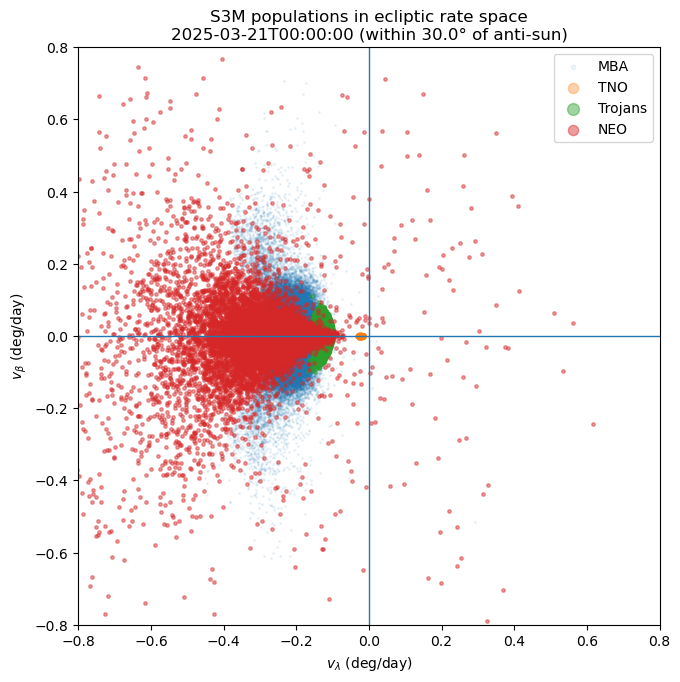

In [42]:
# Plotting limits (matching earlier cells)
xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)

# Down sampling for huge populations 
def downsample(x, y, nmax=250_000, seed=0):
    n = len(x)
    if n <= nmax:
        return x, y
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=nmax, replace=False)
    return x[idx], y[idx]

# Down sampling MBA for visibility/speed
vlam_mba_ds, vbeta_mba_ds = downsample(vlam_mba, vbeta_mba, nmax=250_000, seed=1)

fig, ax = plt.subplots(figsize=(7.5, 7.5))

# Plotting order: big populations first, smaller on top
ax.scatter(vlam_mba_ds, vbeta_mba_ds, s=1, alpha=0.08, label="MBA", rasterized=True)
ax.scatter(vlam_tno,    vbeta_tno,    s=6, alpha=0.35, label="TNO", rasterized=True)
ax.scatter(vlam_tjn,    vbeta_tjn,    s=8, alpha=0.45, label="Trojans", rasterized=True)
ax.scatter(vlam_neo,    vbeta_neo,    s=6, alpha=0.45, label="NEO", rasterized=True)

ax.axhline(0, lw=1)
ax.axvline(0, lw=1)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")

ax.legend(loc="upper right", frameon=True, markerscale=3)
ax.set_title(f"S3M populations in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)")

plt.show()


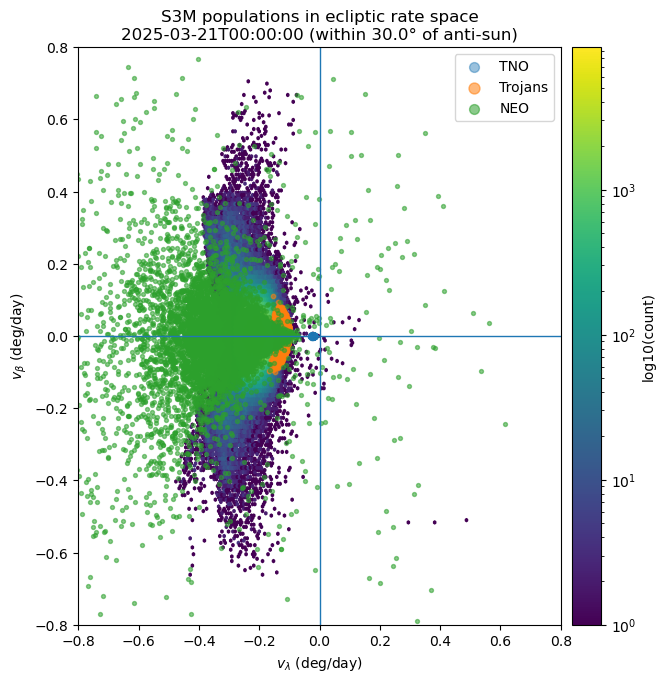

In [43]:
xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)

fig, ax = plt.subplots(figsize=(7.5, 7.5))

# MBA's as a density
hb = ax.hexbin(
    vlam_mba, vbeta_mba,
    gridsize=220,            # bigger = finer pixels (ranges: 160–320)
    extent=(*xlim, *ylim),
    mincnt=1,
    bins="log"               # log density so wings show up
)
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("log10(count)")



\
ax.scatter(vlam_tno, vbeta_tno, s=8,  alpha=0.45, label="TNO",     rasterized=True)
ax.scatter(vlam_tjn, vbeta_tjn, s=10, alpha=0.55, label="Trojans", rasterized=True)
ax.scatter(vlam_neo, vbeta_neo, s=8,  alpha=0.55, label="NEO",     rasterized=True)


ax.axhline(0, lw=1)
ax.axvline(0, lw=1)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")


ax.legend(loc="upper right", frameon=True, markerscale=2.5)

try:
    ax.set_title(f"S3M populations in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)")
except NameError:
    ax.set_title("S3M populations in ecliptic rate space")

plt.show()
